In [2]:
from google.colab import files
uploaded=files.upload()

Saving WA_Fn-UseC_-HR-Employee-Attrition.csv to WA_Fn-UseC_-HR-Employee-Attrition.csv


# Real Business Problem
An organization loses employees every month.

HR wants to predict:
* Which employees are likely to leave
* Why they may leave
* Which factors influence attrition
* Risk category of employees


In [3]:
import pandas as pd
import numpy as np
df=pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [5]:
df.shape

(1470, 35)

In [6]:
df.isnull().sum()

,0
Age,0
Attrition,0
BusinessTravel,0
DailyRate,0
Department,0
DistanceFromHome,0
Education,0
EducationField,0
EmployeeCount,0
EmployeeNumber,0


# Phase 1 — EDA
Identify:

* Attrition rate
* Department-wise attrition
* Gender-wise attrition
* Salary impact
* xperience impact


In [7]:
#Attrition rate analysis
df['Attrition'].value_counts()

,count
Attrition,
No,1233
Yes,237


In [11]:
#attrition rate
att_rate=df['Attrition'].value_counts(normalize=True)*100
att_rate
#

,proportion
Attrition,
No,83.877551
Yes,16.122449


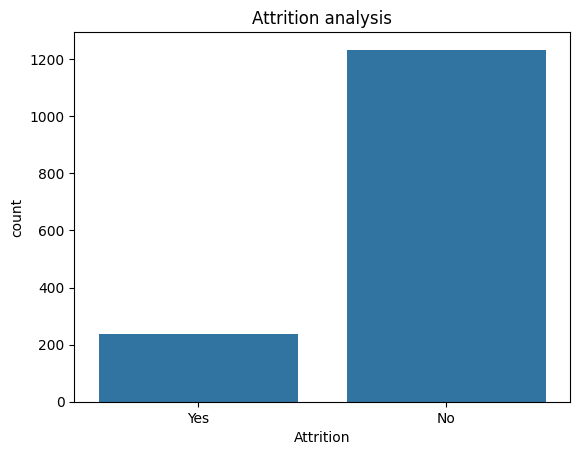

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.countplot(x='Attrition',data=df)
plt.title("Attrition analysis")
plt.show()

**Department wise attrition**

In [13]:
dept_att=pd.crosstab(df['Department'],df['Attrition'])
dept_att

Attrition,No,Yes
Department,,
Human Resources,51,12
Research & Development,828,133
Sales,354,92


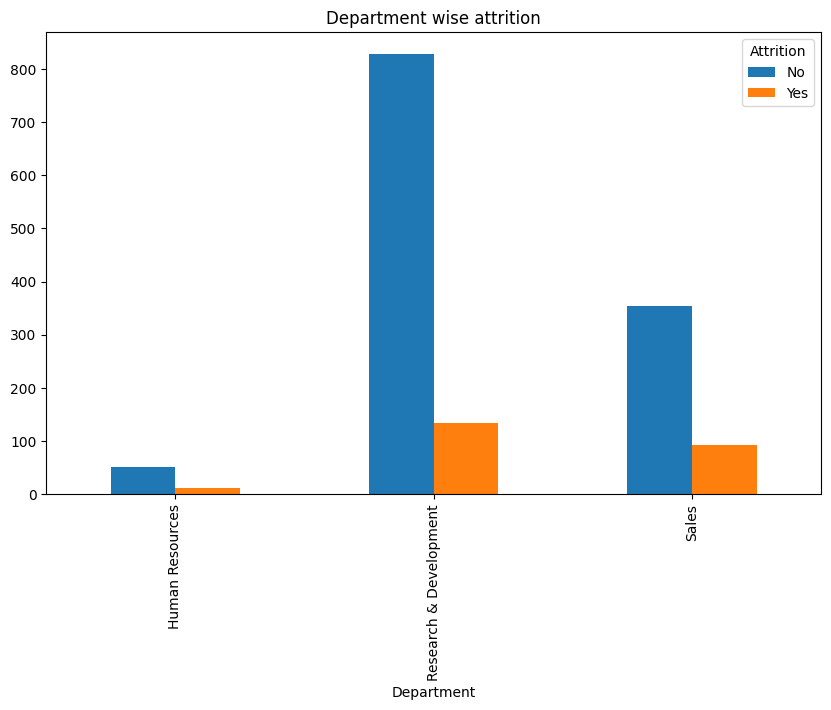

In [14]:
dept_att.plot(kind='bar',figsize=(10,6))
plt.title("Department wise attrition")
plt.show()

**Gender wise attrition**

In [15]:
gen_att=pd.crosstab(df['Gender'],df['Attrition'])
gen_att

Attrition,No,Yes
Gender,,
Female,501,87
Male,732,150


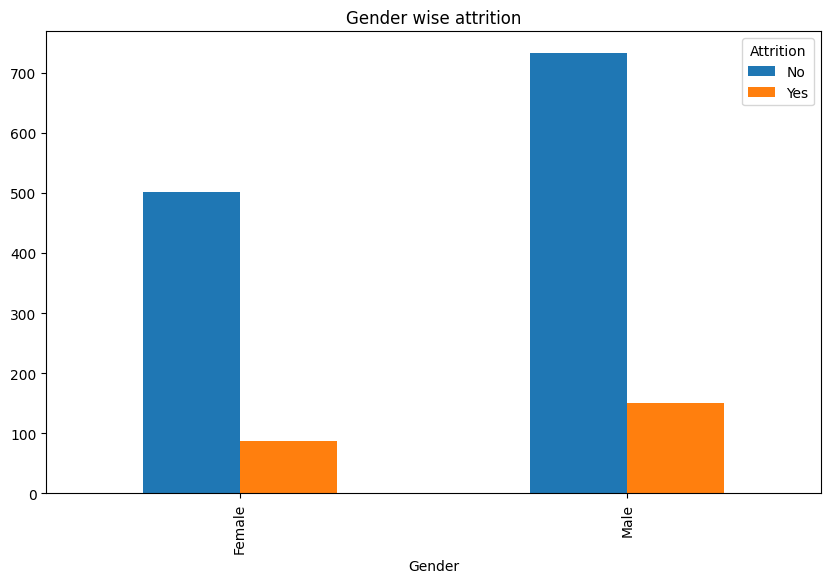

In [17]:
gen_att.plot(kind='bar',figsize=(10,6))
plt.title("Gender wise attrition")
plt.show()

**Salary Impact**

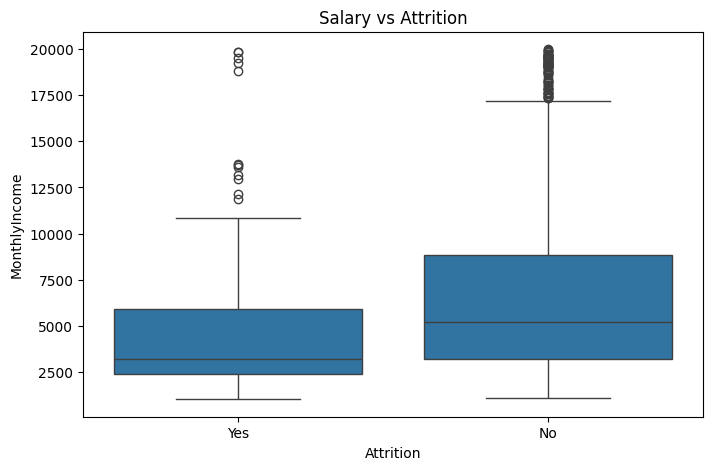

In [21]:
plt.figure(figsize=(8,5))

sns.boxplot(x='Attrition',
            y='MonthlyIncome',
            data=df)

plt.title("Salary vs Attrition")
plt.show()

In [22]:
df.groupby('Attrition')['MonthlyIncome'].mean()

,MonthlyIncome
Attrition,
No,6832.739659
Yes,4787.092827


**Experience impact**

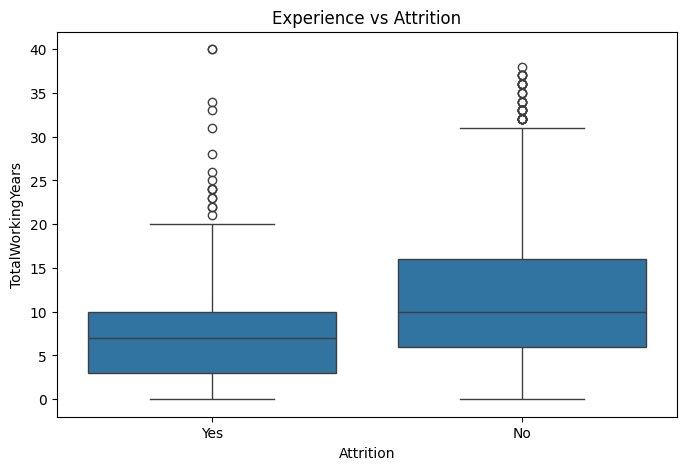

In [23]:
plt.figure(figsize=(8,5))

sns.boxplot(x='Attrition',
            y='TotalWorkingYears',
            data=df)

plt.title("Experience vs Attrition")
plt.show()

In [24]:
df.groupby('Attrition')['TotalWorkingYears'].mean()

,TotalWorkingYears
Attrition,
No,11.862936
Yes,8.244726


**Total factors Analysis**

In [25]:
df.groupby('Attrition')[[
    'Age',
    'MonthlyIncome',
    'JobSatisfaction',
    'YearsAtCompany',
    'TotalWorkingYears'
]].mean()

,Age,MonthlyIncome,JobSatisfaction,YearsAtCompany,TotalWorkingYears
Attrition,,,,,
No,37.561233,6832.739659,2.778589,7.369019,11.862936
Yes,33.607595,4787.092827,2.468354,5.130802,8.244726


# Phase 2 — Machine Learning
* Logistic Regression

Predict:
Attrition = Yes / No

* Decision Tree

Generate HR decision rules.

Example:
IF
JobSatisfaction < 2

AND

MonthlyIncome < 4000

THEN

High Attrition Risk

* Random Forest

Build production model.

* SVM

Compare accuracy.

* KNN

Find similar employees.

* Naive Bayes

Probability-based prediction.

* PCA

Dimensionality reduction.

* K-Means

Employee Segmentation:

Cluster 1:
High Performers

Cluster 2:
At Risk

Cluster 3:
New Employees


In [26]:
#drop unnecessary columns
df.drop(['EmployeeCount',
         'Over18',
         'StandardHours',
         'EmployeeNumber'],
         axis=1,
         inplace=True)

In [27]:
#convert target variable
df['Attrition'] = df['Attrition'].map({
    'Yes':1,
    'No':0
})

In [28]:
#label encoding
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.columns:
    if df[col].dtype=='object':
        df[col] = le.fit_transform(df[col])

In [29]:
#feature and target
X = df.drop('Attrition', axis=1)
y = df['Attrition']

In [30]:
#split the model
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

**logistic regression**

In [32]:
from sklearn.linear_model import LogisticRegression
lr=LogisticRegression(max_iter=5000)
lr.fit(X_train,y_train)

y_pred=lr.predict(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [33]:
from sklearn.metrics import accuracy_score

print("Accuracy:",
      accuracy_score(y_test,y_pred))

Accuracy: 0.8843537414965986


In [34]:
from sklearn.metrics import confusion_matrix

print(confusion_matrix(y_test,y_pred))

[[250   5]
 [ 29  10]]


**Decision tree**

In [35]:
from sklearn.tree import DecisionTreeClassifier
dt=DecisionTreeClassifier(max_depth=5,random_state=42)
dt.fit(X_train,y_train)

y_pred=dt.predict(X_test)

In [36]:
print("Accuracy:",accuracy_score(y_test,y_pred))

Accuracy: 0.826530612244898


In [37]:
print(confusion_matrix(y_test,y_pred))

[[237  18]
 [ 33   6]]


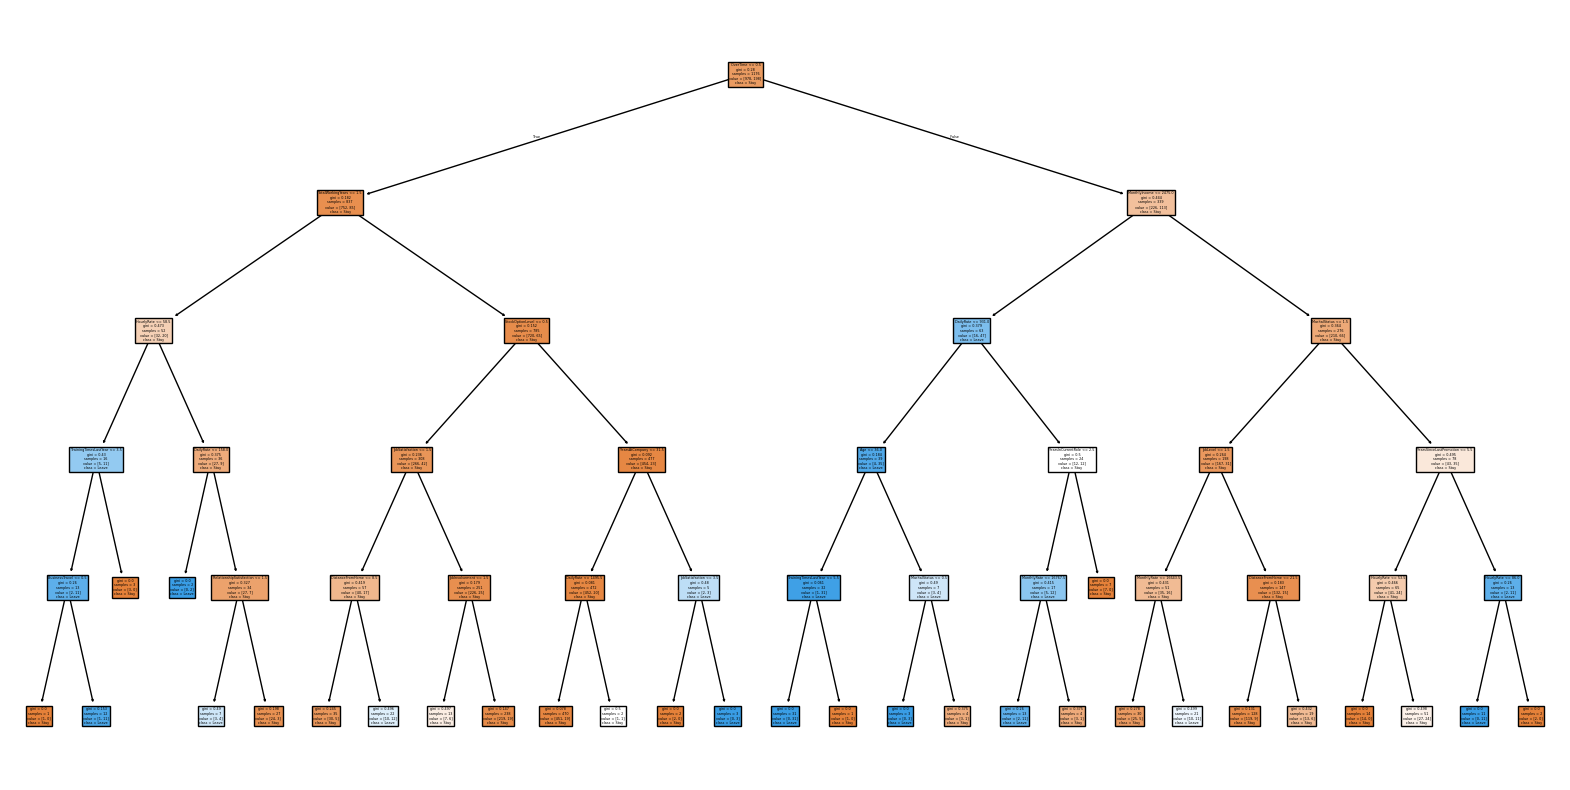

In [38]:
from sklearn.tree import plot_tree
plt.figure(figsize=(20,10))
plot_tree(dt,feature_names=X.columns,class_names=['Stay','Leave'],filled=True)
plt.show()

**Random Forest**

In [45]:
from sklearn.ensemble import RandomForestClassifier
rf=RandomForestClassifier(n_estimators=100,random_state=42)
rf.fit(X_train,y_train)

y_pred=rf.predict(X_test)

In [46]:
print("Accuracy:",accuracy_score(y_test,y_pred))

Accuracy: 0.8809523809523809


In [47]:
print(confusion_matrix(y_test,y_pred))

[[254   1]
 [ 34   5]]


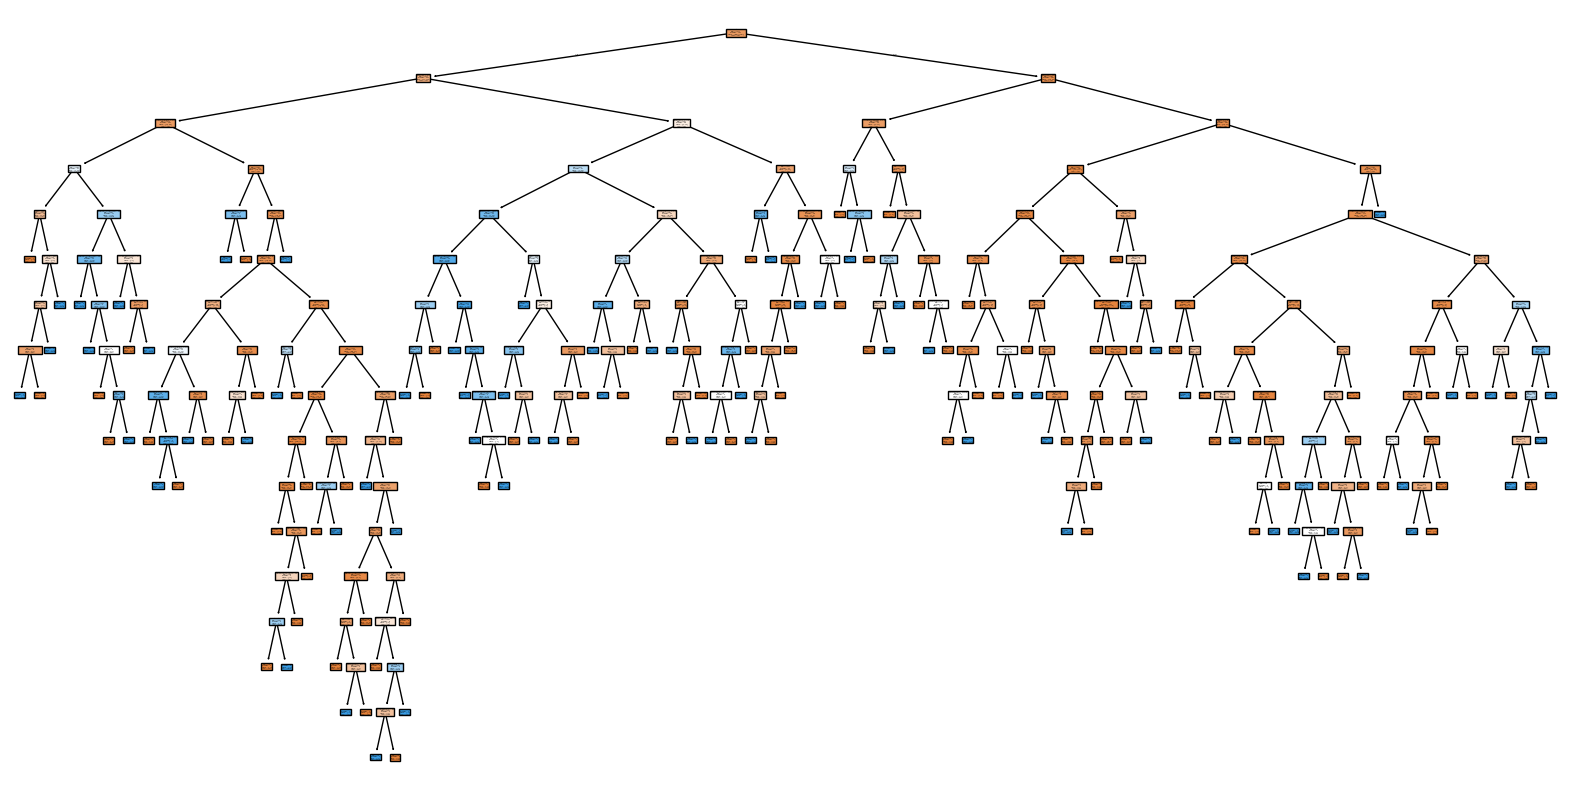

In [48]:
plt.figure(figsize=(20,10))
plot_tree(rf.estimators_[0],feature_names=X.columns,class_names=['Stay','Leave'],filled=True)
plt.show()

In [50]:
#feature importance
importance = pd.DataFrame({
    'Feature':X.columns,
    'Importance':rf.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance.head(10))

               Feature  Importance
15       MonthlyIncome    0.078212
18            OverTime    0.066669
0                  Age    0.061569
2            DailyRate    0.054087
23   TotalWorkingYears    0.052491
16         MonthlyRate    0.048373
9           HourlyRate    0.047369
4     DistanceFromHome    0.045999
26      YearsAtCompany    0.041347
17  NumCompaniesWorked    0.037951


**SVM**

In [53]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [54]:
from sklearn.svm import SVC
svm=SVC()
svm.fit(X_train,y_train)

y_pred=svm.predict(X_test)

In [55]:
print("Accuracy:",accuracy_score(y_test,y_pred))

Accuracy: 0.8673469387755102


**KNN**

In [56]:
from sklearn.neighbors import KNeighborsClassifier
knn=KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train,y_train)

y_pred=knn.predict(X_test)

In [57]:
print("Accuracy:",accuracy_score(y_test,y_pred))

Accuracy: 0.8469387755102041


**Naive Bayes**

In [58]:
from sklearn.naive_bayes import GaussianNB
nb=GaussianNB()
nb.fit(X_train,y_train)

y_pred=nb.predict(X_test)

In [59]:
print("Accuracy:",accuracy_score(y_test,y_pred))

Accuracy: 0.8401360544217688


In [60]:
#probability prediction
nb.predict_proba(X_test)

array([[6.21001452e-01, 3.78998548e-01],
       [9.60170809e-01, 3.98291913e-02],
       [1.67904062e-01, 8.32095938e-01],
       [9.88705670e-01, 1.12943305e-02],
       [9.87591543e-01, 1.24084570e-02],
       [7.28400271e-01, 2.71599729e-01],
       [3.75271775e-01, 6.24728225e-01],
       [9.58082583e-01, 4.19174168e-02],
       [9.97993287e-01, 2.00671310e-03],
       [7.45578983e-01, 2.54421017e-01],
       [1.85612514e-01, 8.14387486e-01],
       [9.99922358e-01, 7.76423994e-05],
       [5.82322009e-01, 4.17677991e-01],
       [9.52809362e-01, 4.71906381e-02],
       [3.05267428e-01, 6.94732572e-01],
       [7.89062508e-01, 2.10937492e-01],
       [3.26747402e-01, 6.73252598e-01],
       [9.99506289e-01, 4.93711081e-04],
       [9.93237465e-01, 6.76253459e-03],
       [9.99928997e-01, 7.10033106e-05],
       [3.05802474e-01, 6.94197526e-01],
       [9.90105695e-01, 9.89430490e-03],
       [8.92911304e-01, 1.07088696e-01],
       [7.63724479e-01, 2.36275521e-01],
       [5.335089

**PCA**

In [61]:
from sklearn.decomposition import PCA

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca=PCA(n_components=2)
X_pca=pca.fit_transform(X_scaled)

print(X_pca.shape)

(1470, 2)


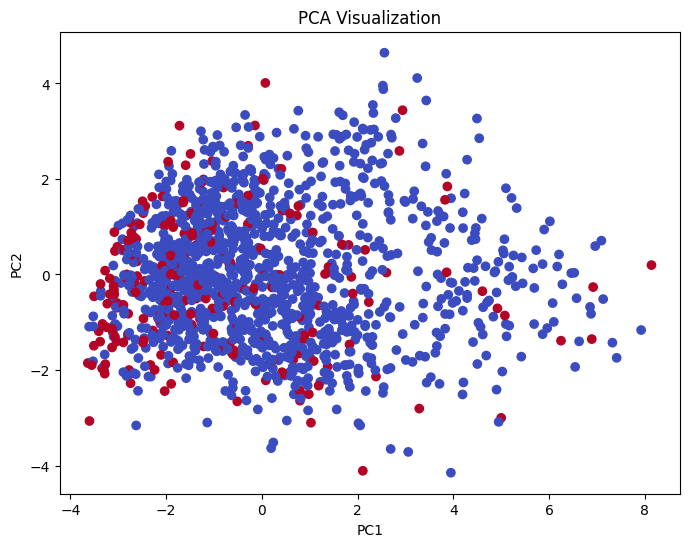

In [62]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=y,
    cmap='coolwarm'
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Visualization")
plt.show()

**K-Means**

In [63]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=3,
    random_state=42
)

clusters = kmeans.fit_predict(X_scaled)

df['Cluster'] = clusters

In [64]:
cluster_summary = df.groupby(
    'Cluster'
).mean()

print(cluster_summary)

               Age  Attrition  BusinessTravel   DailyRate  Department  \
Cluster                                                                 
0        34.599738   0.171916        1.603675  798.354331    0.934383   
1        34.664865   0.218919        1.594595  815.767568    1.994595   
2        44.636095   0.073964        1.630178  797.260355    1.192308   

         DistanceFromHome  Education  EducationField  EnvironmentSatisfaction  \
Cluster                                                                         
0                9.127297   2.846457        2.300525                 2.706037   
1                9.610811   2.905405        2.186486                 2.678378   
2                8.881657   3.071006        2.195266                 2.804734   

           Gender  ...  PerformanceRating  RelationshipSatisfaction  \
Cluster            ...                                                
0        0.631234  ...           3.160105                  2.719160   
1        0.5918

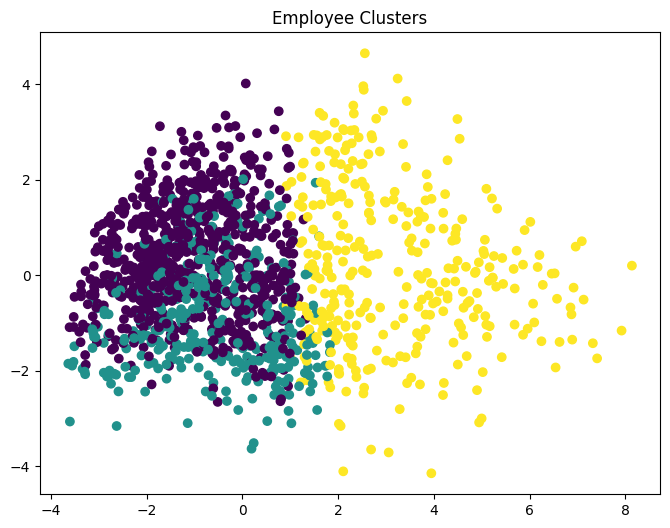

In [65]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=clusters,
    cmap='viridis'
)

plt.title("Employee Clusters")
plt.show()

# Save the models

In [66]:
import joblib

joblib.dump(lr, "logistic_regression.pkl")

['logistic_regression.pkl']

In [67]:
joblib.dump(rf, "random_forest.pkl")

['random_forest.pkl']

In [68]:
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [69]:
joblib.dump(le, "label_encoder.pkl")

['label_encoder.pkl']

# download

In [70]:
from google.colab import files

files.download("logistic_regression.pkl")
files.download("random_forest.pkl")
files.download("scaler.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>